# Library and Package

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# Load the Dataset

In [2]:
df = pd.read_csv('in-vehicle-coupon-recommendation.csv')
print(df.shape)

#check missing values
df.isnull().sum()

(12684, 26)


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

# Clean Column Names

In [3]:
import re

def clean_columns(df):

    df.columns = [str(col) for col in df.columns]

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]

    df.columns = [
        re.sub(r'_+', '_', col).strip('_')
        for col in df.columns
    ]

    return df

# Data Splitting

In [ ]:
#split the features and the target variables
X = df.drop('Y', axis=1)
y = df['Y']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handling Missing Values

In [4]:
#handle the missing value 
df = df.drop(columns=['car'])

#fill the missing value
cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0]) #mode imputation method

#drop occupation column
df = df.drop(columns=['occupation'])

#check the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  income                12684 non-null  object
 13  Bar                   12684 non-null  object
 14  CoffeeHouse           12684 non-null  object
 15  CarryAway             12684 non-null

# Encoding Categorical Features

In [6]:
#define ordinal and nominal columns
nom_cols = ['destination', 'passanger', 'weather', 'time', 'coupon', 'expiration', 'gender', 'maritalStatus']
ord_cols = ['age', 'education', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

#intialize encoders
ohe_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

#==================process training data===================
#nominal label
X_train_nom_array = ohe_enc.fit_transform(X_train[nom_cols])
X_train_nom_df = pd.DataFrame(X_train_nom_array, columns=ohe_enc.get_feature_names_out(), index=X_train.index)

# CLEAN COLUMN NAMES
X_train_nom_df = clean_columns(X_train_nom_df)

#ordinal label
X_train_ord_array = ord_enc.fit_transform(X_train[ord_cols])
X_train_ord_df = pd.DataFrame(X_train_ord_array, columns=ord_cols, index=X_train.index)

#merge them back
X_train = pd.concat([X_train_nom_df, X_train_ord_df], axis=1)

#==================process testing data====================
#nominal label
X_test_nom_array = ohe_enc.transform(X_test[nom_cols])
X_test_nom_df = pd.DataFrame(X_test_nom_array, columns=ohe_enc.get_feature_names_out(), index=X_test.index)
X_test_nom_df = clean_columns(X_test_nom_df)
#ordinal label
X_test_ord_array = ord_enc.transform(X_test[ord_cols])
X_test_ord_df = pd.DataFrame(X_test_ord_array, columns=ord_cols, index=X_test.index)

#merge them back
X_test = pd.concat([X_test_nom_df, X_test_ord_df], axis=1)

print(X_train.shape)
print(X_test.shape)

print(X_train.head)


(10147, 29)
(2537, 29)
<bound method NDFrame.head of        destination_No_Urgent_Place  destination_Work  passanger_Friend_s  \
9553                           0.0               1.0                 0.0   
1394                           1.0               0.0                 1.0   
552                            1.0               0.0                 1.0   
8377                           0.0               0.0                 0.0   
1353                           1.0               0.0                 1.0   
...                            ...               ...                 ...   
1062                           1.0               0.0                 1.0   
2812                           1.0               0.0                 0.0   
11414                          1.0               0.0                 1.0   
546                            1.0               0.0                 1.0   
11504                          1.0               0.0                 0.0   

       passanger_Kid_s  passanger_

# Feature Selection

In [7]:
selector = SelectKBest(score_func=chi2, k=20)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print(selected_features)

Index(['destination_No_Urgent_Place', 'destination_Work', 'passanger_Friend_s',
       'weather_Snowy', 'weather_Sunny', 'time_10PM', 'time_2PM', 'time_7AM',
       'coupon_Carry_out_Take_away', 'coupon_Coffee_House',
       'coupon_Restaurant_20_50', 'coupon_Restaurant_20', 'expiration_2h',
       'maritalStatus_Single', 'age', 'education', 'Bar', 'CoffeeHouse',
       'CarryAway', 'Restaurant20To50'],
      dtype='object')


# Save the preprocessed data

In [8]:
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features)

train_final = pd.concat([X_train_selected, y_train.reset_index(drop=True)], axis=1)
test_final = pd.concat([X_test_selected, y_test.reset_index(drop=True)], axis=1)

train_final.to_csv("train_data.csv", index=False)
test_final.to_csv("test_data.csv", index=False)

# Training Loop Preparation

The processed training dataset is loaded and divided into:
- Training set
- Validation set

The validation set is used to monitor model performance during training and reduce overfitting.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Load processed training data
train_df = pd.read_csv("train_data.csv")

# Separate features and target
X = train_df.drop("Y", axis=1)
y = train_df["Y"]

print("Processed training data loaded successfully!")
print("Feature shape:", X.shape)

Processed training data loaded successfully!
Feature shape: (10147, 20)


## Create Training and Validation Sets

In [11]:
# Split into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

Training set shape: (8117, 20)
Validation set shape: (2030, 20)


# Initialize XGBoost Model

In [12]:
model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.005,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric=['logloss', 'error'],
    early_stopping_rounds=500
)

# Execute Training Loop

The XGBoost model is trained using:
- Training dataset
- Validation dataset

Early stopping is applied to reduce overfitting by stopping training when validation performance no longer improves.

In [13]:
# Create evaluation set

eval_set = [
    (X_train, y_train),
    (X_val, y_val)
]

print("Evaluation set created successfully!")

Evaluation set created successfully!


In [14]:
print("Starting XGBoost training loop...")

model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=50
)

Starting XGBoost training loop...
[0]	validation_0-logloss:0.68273	validation_0-error:0.43156	validation_1-logloss:0.68282	validation_1-error:0.43153
[50]	validation_0-logloss:0.64038	validation_0-error:0.37514	validation_1-logloss:0.64715	validation_1-error:0.38325
[100]	validation_0-logloss:0.60899	validation_0-error:0.28767	validation_1-logloss:0.62202	validation_1-error:0.30345
[150]	validation_0-logloss:0.58417	validation_0-error:0.25785	validation_1-logloss:0.60259	validation_1-error:0.28670
[200]	validation_0-logloss:0.56326	validation_0-error:0.24824	validation_1-logloss:0.58754	validation_1-error:0.28276
[250]	validation_0-logloss:0.54654	validation_0-error:0.23999	validation_1-logloss:0.57597	validation_1-error:0.27586
[300]	validation_0-logloss:0.53223	validation_0-error:0.23395	validation_1-logloss:0.56656	validation_1-error:0.27241
[350]	validation_0-logloss:0.52014	validation_0-error:0.22866	validation_1-logloss:0.55946	validation_1-error:0.27044
[400]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=500,
              enable_categorical=False, eval_metric=['logloss', 'error'],
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.005, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

# Validation Performance Evaluation

In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Generate predictions
y_pred = model.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy: 75.02%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       876
           1       0.77      0.81      0.79      1154

    accuracy                           0.75      2030
   macro avg       0.75      0.74      0.74      2030
weighted avg       0.75      0.75      0.75      2030



# Training Progress Visualization

The training and validation log loss are visualized across boosting rounds to monitor:
- learning progress
- convergence
- overfitting behaviour

In [16]:
# Retrieve evaluation results

results = model.evals_result()

# Number of boosting rounds
epochs = len(results['validation_0']['error'])

# X-axis values
x_axis = range(0, epochs)

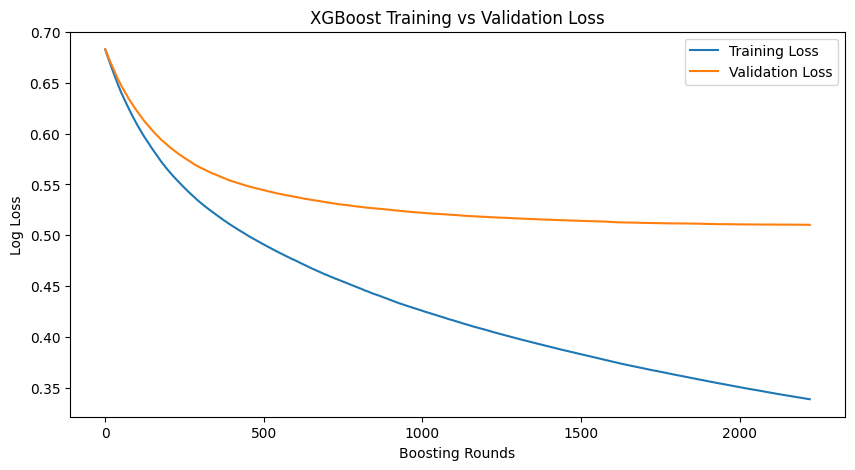

In [17]:
plt.figure(figsize=(10, 5))

# Training loss
plt.plot(
    x_axis,
    results['validation_0']['logloss'],
    label='Training Loss'
)

# Validation loss
plt.plot(
    x_axis,
    results['validation_1']['logloss'],
    label='Validation Loss'
)

# Labels and title
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('XGBoost Training vs Validation Loss')

# Legend
plt.legend()

# Show graph
plt.show()

# Model Optimization using Cross-Validation

To further improve model generalization and reduce overfitting, the baseline XGBoost configuration from Milestone 3 was evaluated using 5-fold stratified cross-validation.

The optimization process measures:
- training accuracy
- validation accuracy
- overfitting gap

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_val_scores = []
base_gaps       = []

print('--- BASELINE MODEL (M3 Config) ---')
for fold, (ti, vi) in enumerate(cv.split(X_train, y_train)):
    model = xgb.XGBClassifier(
        learning_rate=0.005,  n_estimators=5000,
        max_depth=8,          reg_alpha=0.1,
        reg_lambda=1.0,       subsample=0.8,
        colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1,            early_stopping_rounds=50,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train.iloc[ti], y_train.iloc[ti],
          eval_set=[(X_train.iloc[vi], y_train.iloc[vi])], verbose=False)

    tr_acc  = accuracy_score(y_train.iloc[ti], model.predict(X_train.iloc[ti]))
    val_acc = accuracy_score(y_train.iloc[vi], model.predict(X_train.iloc[vi]))
    gap     = tr_acc - val_acc

    base_val_scores.append(val_acc)
    base_gaps.append(gap)
    print(f'  Fold {fold+1}: Train={tr_acc:.4f} | Val={val_acc:.4f} | Gap={gap:.4f}')

print(f'\nBaseline CV Val Mean : {np.mean(base_val_scores):.4f} | Std: {np.std(base_val_scores):.4f}')
print(f'Baseline Avg Gap     : {np.mean(base_gaps):.4f}  <-- overfitting')


--- BASELINE MODEL (M3 Config) ---
  Fold 1: Train=0.8766 | Val=0.7371 | Gap=0.1396
  Fold 2: Train=0.8794 | Val=0.7371 | Gap=0.1423
  Fold 3: Train=0.8636 | Val=0.7166 | Gap=0.1470
  Fold 4: Train=0.8751 | Val=0.7283 | Gap=0.1468
  Fold 5: Train=0.8668 | Val=0.7258 | Gap=0.1410

Baseline CV Val Mean : 0.7290 | Std: 0.0077
Baseline Avg Gap     : 0.1433  <-- overfitting


In [19]:
opt_val_scores = []
opt_gaps       = []

print('--- OPTIMIZED MODEL (M4 Config) ---')
for fold, (ti, vi) in enumerate(cv.split(X_train, y_train)):
    model = xgb.XGBClassifier(
        learning_rate=0.01,   n_estimators=500,
        max_depth=4,          reg_alpha=0.5,
        reg_lambda=2.0,       subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        gamma=0.1,            early_stopping_rounds=30,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train.iloc[ti], y_train.iloc[ti],
          eval_set=[(X_train.iloc[vi], y_train.iloc[vi])], verbose=False)

    tr_acc  = accuracy_score(y_train.iloc[ti], model.predict(X_train.iloc[ti]))
    val_acc = accuracy_score(y_train.iloc[vi], model.predict(X_train.iloc[vi]))
    gap     = tr_acc - val_acc

    opt_val_scores.append(val_acc)
    opt_gaps.append(gap)
    print(f'  Fold {fold+1}: Train={tr_acc:.4f} | Val={val_acc:.4f} | Gap={gap:.4f}')

print(f'\nOptimized CV Val Mean : {np.mean(opt_val_scores):.4f} | Std: {np.std(opt_val_scores):.4f}')
print(f'Optimized Avg Gap     : {np.mean(opt_gaps):.4f}  <-- reduced')

gap_reduction = (np.mean(base_gaps) - np.mean(opt_gaps)) / np.mean(base_gaps) * 100
print(f'\nGap Reduction: {gap_reduction:.1f}%')


--- OPTIMIZED MODEL (M4 Config) ---
  Fold 1: Train=0.7243 | Val=0.7057 | Gap=0.0187
  Fold 2: Train=0.7235 | Val=0.6952 | Gap=0.0284
  Fold 3: Train=0.7227 | Val=0.7006 | Gap=0.0221
  Fold 4: Train=0.7199 | Val=0.7123 | Gap=0.0076
  Fold 5: Train=0.7207 | Val=0.7061 | Gap=0.0146

Optimized CV Val Mean : 0.7040 | Std: 0.0057
Optimized Avg Gap     : 0.0183  <-- reduced

Gap Reduction: 87.3%


In [ ]:
opt_val_scores = []
opt_gaps       = []

print('--- OPTIMIZED MODEL (M4 Config) ---')
for fold, (ti, vi) in enumerate(cv.split(X_train, y_train)):
    model = xgb.XGBClassifier(
        learning_rate=0.01,   n_estimators=500,
        max_depth=4,          reg_alpha=0.5,
        reg_lambda=2.0,       subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        gamma=0.1,            early_stopping_rounds=30,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train.iloc[ti], y_train.iloc[ti],
          eval_set=[(X_train.iloc[vi], y_train.iloc[vi])], verbose=False)

    tr_acc  = accuracy_score(y_train.iloc[ti], model.predict(X_train.iloc[ti]))
    val_acc = accuracy_score(y_train.iloc[vi], model.predict(X_train.iloc[vi]))
    gap     = tr_acc - val_acc

    opt_val_scores.append(val_acc)
    opt_gaps.append(gap)
    print(f'  Fold {fold+1}: Train={tr_acc:.4f} | Val={val_acc:.4f} | Gap={gap:.4f}')

print(f'\nOptimized CV Val Mean : {np.mean(opt_val_scores):.4f} | Std: {np.std(opt_val_scores):.4f}')
print(f'Optimized Avg Gap     : {np.mean(opt_gaps):.4f}  <-- reduced')

gap_reduction = (np.mean(base_gaps) - np.mean(opt_gaps)) / np.mean(base_gaps) * 100
print(f'\nGap Reduction: {gap_reduction:.1f}%')


--- OPTIMIZED MODEL (M4 Config) ---
  Fold 1: Train=0.7243 | Val=0.7057 | Gap=0.0187
  Fold 2: Train=0.7235 | Val=0.6952 | Gap=0.0284


# Save Optimized Model

The optimized XGBoost model is saved for:
- reproducibility
- future deployment
- final testing
- model reuse without retraining

In [ ]:
import joblib

# Save optimized model
joblib.dump(model, "best_xgboost_model.pkl")

print("Optimized model saved successfully!")

Optimized model saved successfully!


# Final Model Evaluation on Test Dataset

The optimized XGBoost model was evaluated using the unseen testing dataset to measure real-world predictive performance.

The evaluation includes:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC
- Precision-Recall AUC

Additional visualizations were generated to analyze classification performance.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

## Load Testing Dataset

In [ ]:
test = pd.read_csv('test_data.csv')

X_test = test.drop('Y', axis=1)
y_test = test['Y']

print("Testing dataset loaded successfully!")

Testing dataset loaded successfully!


## Load Optimized Model

In [ ]:
import joblib

model = joblib.load(
    "best_xgboost_model.pkl"
)

print("Optimized model loaded successfully!")

Optimized model loaded successfully!


## Generate Predictions

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

## Model Performance Metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))

Accuracy : 0.7087
Precision: 0.7204
Recall   : 0.7968
F1-Score : 0.7567
ROC-AUC  : 0.7676
PR-AUC   : 0.7995


## Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.59      0.64      1095
           1       0.72      0.80      0.76      1442

    accuracy                           0.71      2537
   macro avg       0.70      0.69      0.70      2537
weighted avg       0.71      0.71      0.71      2537



## Confusion Matrix

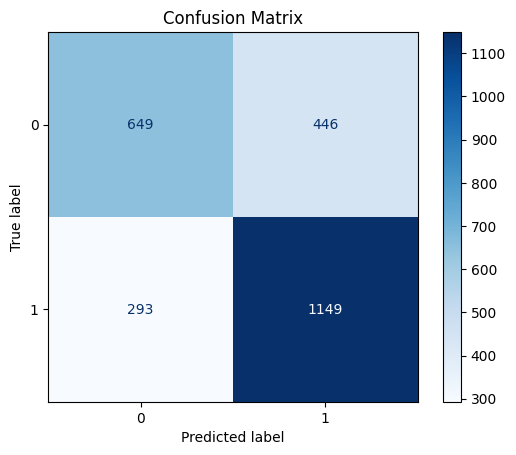

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

## ROC Curve

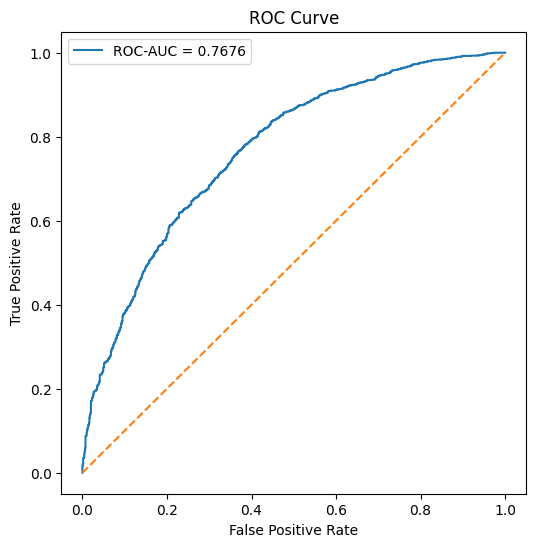

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Precision-Recall Curve

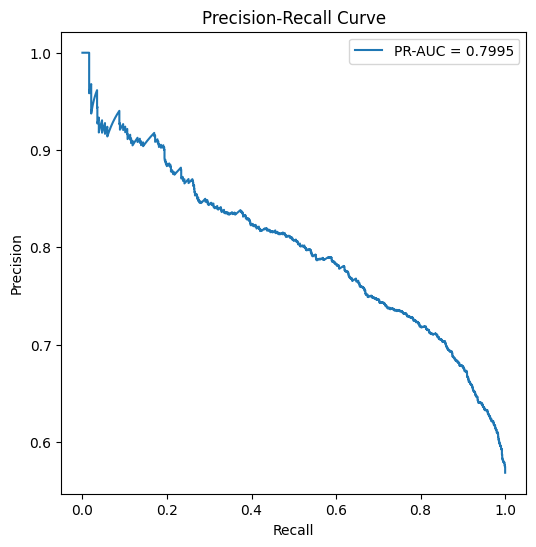

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f'PR-AUC = {pr_auc:.4f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

## Overall Performance Visualization

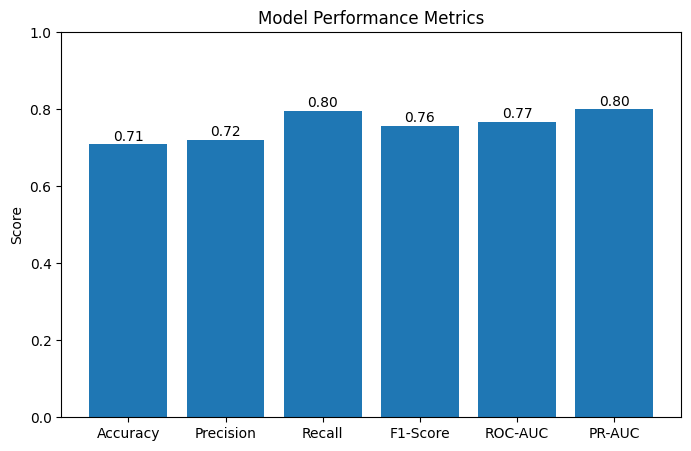

In [ ]:
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'PR-AUC': pr_auc
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8,5))

bars = plt.bar(names, values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Performance Metrics")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f'{yval:.2f}',
        ha='center'
    )

plt.show()